In [1]:
import pandas as pd
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from torch.utils.data import Dataset, DataLoader

from config import *

In [2]:
train_df = pd.read_csv(TRAIN_CSV)
train_df.head()

,Review,Liked
0,perfect sitdown family meal get together friend,1
1,service slow not attentive,0
2,food outstanding price reasonable,1
3,two bite refused eat anymore,0
4,not gone go,1


In [3]:
reviews = train_df["Review"]
labels = train_df["Liked"]
print(reviews.shape)
print(labels.shape)

(800,)
(800,)


In [4]:
vectorizer = TfidfVectorizer(
    ngram_range=NGRAM_RANGE,
    max_features=MAX_FEATURES
)
X_train = vectorizer.fit_transform(reviews)
y_train = labels.values

X_train = X_train.toarray()

In [5]:
from src.Dataset import ReviewDataset
from torch.utils.data import DataLoader

train_dataset = ReviewDataset(
    X_train,
    y_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [6]:
import pickle

with open(VECTORIZER_PATH, "wb") as f:
    pickle.dump(vectorizer, f)

In [7]:
from src.Net import Net

net = Net()

print(net)

Net(
  (network): Sequential(
    (0): Linear(in_features=4932, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [8]:
for batch_features, batch_labels in train_loader:
    output = net(batch_features)

    print(output.shape)
    break

torch.Size([16, 2])


In [9]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    net.parameters(),
    lr=LEARNING_RATE
)

In [10]:
epochs = EPOCHS

loss_history = []

for epoch in range(epochs):
    running_loss = 0.0
    for batch_features, batch_labels in train_loader:
        # Reset gradients
        optimizer.zero_grad()
        # Forward pass
        outputs = net(batch_features)
        # Calculate loss
        loss = criterion(outputs, batch_labels)
        # Backpropagation
        loss.backward()
        # Update weights
        optimizer.step()
        running_loss += loss.item()


    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)
    print(
        f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}"
    )

Epoch [1/20] Loss: 0.6929
Epoch [2/20] Loss: 0.4509
Epoch [3/20] Loss: 0.0479
Epoch [4/20] Loss: 0.0022
Epoch [5/20] Loss: 0.0003
Epoch [6/20] Loss: 0.0004
Epoch [7/20] Loss: 0.0001
Epoch [8/20] Loss: 0.0002
Epoch [9/20] Loss: 0.0000
Epoch [10/20] Loss: 0.0000
Epoch [11/20] Loss: 0.0000
Epoch [12/20] Loss: 0.0001
Epoch [13/20] Loss: 0.0000
Epoch [14/20] Loss: 0.0000
Epoch [15/20] Loss: 0.0000
Epoch [16/20] Loss: 0.0000
Epoch [17/20] Loss: 0.0000
Epoch [18/20] Loss: 0.0000
Epoch [19/20] Loss: 0.0000
Epoch [20/20] Loss: 0.0000


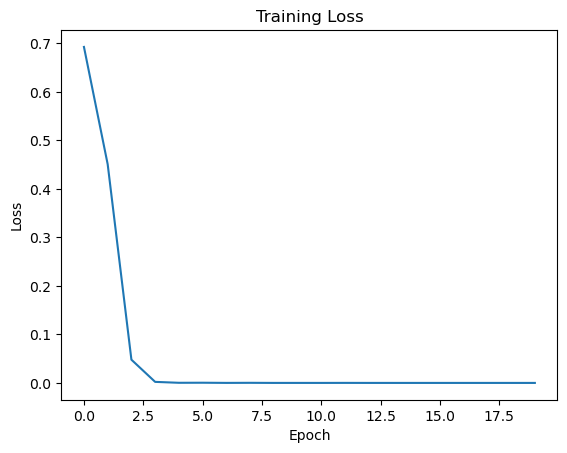

<Figure size 640x480 with 0 Axes>

In [11]:

import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()
plt.savefig(f"./experiments/{MODEL_NAME}_loss_curve")

In [12]:
torch.save(
    net.state_dict(),
    MODEL_PATH
)

In [13]:
experiment_path = f"./logs/[{MODEL_NAME}]_log.txt"

with open(experiment_path, "w") as f:

    f.write(f"""
Experiment: {MODEL_NAME}

====================
Dataset
====================

Training samples:
{len(train_dataset)}


====================
Training Parameters
====================

Seed:
{SEED}

Batch size:
{BATCH_SIZE}

Epochs:
{EPOCHS}


====================
Optimizer
====================

Optimizer:
AdamW

Learning rate:
{LEARNING_RATE}


====================
Loss
====================

CrossEntropyLoss
Label smoothing:
0.0


====================
Saved Model
====================

Path:
{MODEL_PATH}
""")

print(f"Experiment saved to: {experiment_path}")

Experiment saved to: ./logs/[sentiment_model_wider]_log.txt
